# 01 · Analysis units and baseline covariates

**Question:** How were the Section 1 and control units built, and how different were the two groups before construction?

**Mirrors scripts:** `python/01_build_control_units.py` and `python/02_segment_covariates.py`.

**Inputs:** control centrelines, Section 1 units and footprint (`data/vectors/`); panel table (`data/tables/`).
**Outputs:** `results/vectors/C_segment_zones.shp`, `C_segments.shp`, `C_footprint.shp`, `segment_zones_all.shp`; `results/seg_cov.csv`.

### Why controls are needed
Vegetation along the Lekki corridor was disappearing long before the road, because Lagos is growing eastwards. Measuring loss in Section 1 alone would mix the road's effect with that urbanisation. Control coastline, similar coast with no highway, shows what would have happened anyway. The difference between the two is the part attributable to the road.

### How the controls were chosen
Candidate coast west of Lagos Harbour (towards Badagry) and east of Section 1 was screened in 24 stretches of about 5 km, comparing Esri Wayback and PlanetScope imagery from 2020 and 2025–26. Four stretches were rejected: one inside a 10 km exclusion zone around Section 1, one containing the Dangote refinery and Lekki Deep Sea Port, one containing the Lekki Free Trade Zone, and one with unusable 2020 imagery (`data/tables/control_screening.xlsx`). Ordinary settlement growth was *not* a reason to reject a stretch, because that is exactly the background change the controls must capture. A centreline was then digitised behind the beach along each accepted coast.

In [1]:
# --- Setup: find the repository folders (works from notebooks/ or the repo root) ---
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'python'))
from paths import DATA, VEC, RAS, TAB, VAL, RES, ZONES, CRS   # shared folder locations
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False})
print('Repository root found:', ROOT.name)

Repository root found: lagos-calabar-s1-vegetation-loss


## 1. Load the control centrelines

**Note:** the two shapefile names are swapped. `C_linesWest` actually holds the *eastern* line and `ClinesEast` the *western* one, so they are assigned the other way round here. Lines are oriented west → east so segment numbers increase eastwards, as for Section 1 (T01 → T47).

In [2]:
import shapefile, shutil, collections
from shapely.geometry import shape, LineString, MultiPoint, box, mapping
from shapely.ops import substring, voronoi_diagram, unary_union
from shapely.strtree import STRtree

PRJ = str(VEC / 'C_linesWest.prj')
OUT = RES / 'vectors'
HALF = 69.4 / 2          # half the mean width of the Section 1 footprint (m)

def load(n):
    return shape(shapefile.Reader(str(VEC / n)).shape(0).__geo_interface__)

lines = {'W': load('ClinesEast'), 'E': load('C_linesWest')}   # file names are swapped
for side, ln in lines.items():
    if ln.coords[0][0] > ln.coords[-1][0]:
        lines[side] = LineString(ln.coords[::-1])             # orient west -> east
    print(f'{side}: {lines[side].length/1000:.1f} km')

W: 66.3 km
E: 44.5 km


## 2. Cut into 1 km segments and build the zones

For each control line:

1. **Segments.** Cut into consecutive 1 km pieces; the last piece takes the remainder (1–2 km).
2. **Pseudo-footprint.** Buffer the line by 34.7 m each side (69.4 m wide, the same as the real footprint).
3. **Bands.** Rings at 0–500 m, 500 m–1 km and 1–5 km from the footprint edge. The western outer limit is cut at the start of the line so it does not run into Benin.
4. **Splitting bands between segments.** Buffers are continuous, so each ring must be divided between neighbouring segments. Points are placed every 25 m along each segment, their **Voronoi cells** are built, and cells are merged per segment. Every piece of land then belongs to the nearest segment, which gives perpendicular-like cuts even where the coast curves.
5. **Unit** = segment cell ∩ zone ring.

In [3]:
out_units, out_segs, out_fp = [], [], []
for side, ln in lines.items():
    L = ln.length; n = int(L // 1000)
    cuts = [i * 1000 for i in range(n)] + [L]
    segs = [substring(ln, cuts[i], cuts[i + 1]) for i in range(n)]
    ids = [f'C{side}{i + 1:02d}' for i in range(n)]
    fp = ln.buffer(HALF)
    outer = fp.buffer(5000)
    if side == 'W':   # do not extend into Benin beyond the line start
        x0 = ln.coords[0][0]
        outer = outer.intersection(box(x0, outer.bounds[1] - 1, outer.bounds[2] + 1, outer.bounds[3] + 1))

    # Voronoi cells of dense points, merged per segment
    pts, lab = [], []
    for sid, s in zip(ids, segs):
        k = max(2, int(s.length // 25) + 1)
        for j in range(k):
            pts.append(s.interpolate(j / (k - 1), normalized=True)); lab.append(sid)
    vor = voronoi_diagram(MultiPoint(pts), envelope=outer.buffer(2000).envelope)
    tree = STRtree(pts)
    groups = {sid: [] for sid in ids}
    for cell in vor.geoms:
        idx = tree.query(cell, predicate='contains')
        if len(idx):
            groups[lab[idx[0]]].append(cell)
    cells = {sid: unary_union(groups[sid]).intersection(outer) for sid in ids}

    # zone rings
    rings, prev = [(0, 'F', fp)], fp
    for d, z in [(500, 'B1'), (1000, 'B2'), (5000, 'B3')]:
        rings.append((d, z, fp.buffer(d).difference(prev.buffer(0)).intersection(outer))); prev = fp.buffer(d)

    for sid, s in zip(ids, segs):
        out_segs.append((sid, side, s))
        for d, z, rg in rings:
            g = cells[sid].intersection(rg)
            if not g.is_empty and g.area > 1:
                out_units.append((sid, z, side, g.buffer(0)))
    out_fp.append((side, fp))
    print(f'{side}: {n} segments, last segment {segs[-1].length:.0f} m, '
          f'{sum(1 for u in out_units if u[2] == side)} units')

W: 66 segments, last segment 1271 m, 264 units


E: 44 segments, last segment 1472 m, 176 units


## 3. Save, merge with Section 1, and check

The control units are written out and merged with the 188 Section 1 units into `segment_zones_all`, the layer uploaded to Earth Engine. Three checks: every unit id is unique, no geometry is invalid, and the controls neither overlap Section 1 nor come too close to it.

In [4]:
def polyw(name, rows, fields):
    w = shapefile.Writer(name, shapeType=shapefile.POLYGON)
    for f in fields: w.field(*f)
    for rec, g in rows:
        w.shape(mapping(g)); w.record(*rec)
    w.close(); shutil.copy(PRJ, name + '.prj'); open(name + '.cpg', 'w').write('UTF-8')

F5 = [('seg_id', 'C', 6), ('zone', 'C', 3), ('treated', 'N', 2, 0), ('unit_id', 'C', 10), ('side', 'C', 3)]
polyw(str(OUT / 'C_segment_zones'), [((s, z, 0, f'{s}_{z}', side), g) for s, z, side, g in out_units], F5)
w = shapefile.Writer(str(OUT / 'C_segments'), shapeType=shapefile.POLYLINE)
w.field('seg_id', 'C', 6); w.field('side', 'C', 3); w.field('length_m', 'N', 10, 1)
for sid, side, s in out_segs:
    w.line([list(s.coords)]); w.record(sid, side, round(s.length, 1))
w.close(); shutil.copy(PRJ, str(OUT / 'C_segments.prj'))
polyw(str(OUT / 'C_footprint'), [((side,), g) for side, g in out_fp], [('side', 'C', 3)])

s1 = shapefile.Reader(str(VEC / 'S1_segment_zones'))
allrows = [((r.record['seg_id'], r.record['zone'], 1, r.record['unit_id'], 'S1'), shape(r.shape.__geo_interface__))
           for r in s1.iterShapeRecords()]
allrows += [((s, z, 0, f'{s}_{z}', side), g) for s, z, side, g in out_units]
polyw(str(OUT / 'segment_zones_all'), allrows, F5)

ids = [r[0][3] for r in allrows]
fpS = shape(shapefile.Reader(str(VEC / 'S1_footprint_diss')).shape(0).__geo_interface__)
cu = unary_union([g for rec, g in allrows if rec[2] == 0])
s1u = unary_union([g for rec, g in allrows if rec[2] == 1])
print(f'units: {len(allrows)}  unique ids: {len(set(ids))}  invalid geometries: {sum(not g.is_valid for _, g in allrows)}')
print(f'nearest control to the Section 1 footprint: {cu.distance(fpS)/1000:.1f} km')
print(f'overlap between Section 1 and control units: {cu.intersection(s1u).area/1e4:.2f} ha')

units: 628  unique ids: 628  invalid geometries: 0
nearest control to the Section 1 footprint: 8.4 km
overlap between Section 1 and control units: 0.00 ha


## 4. Map of the design

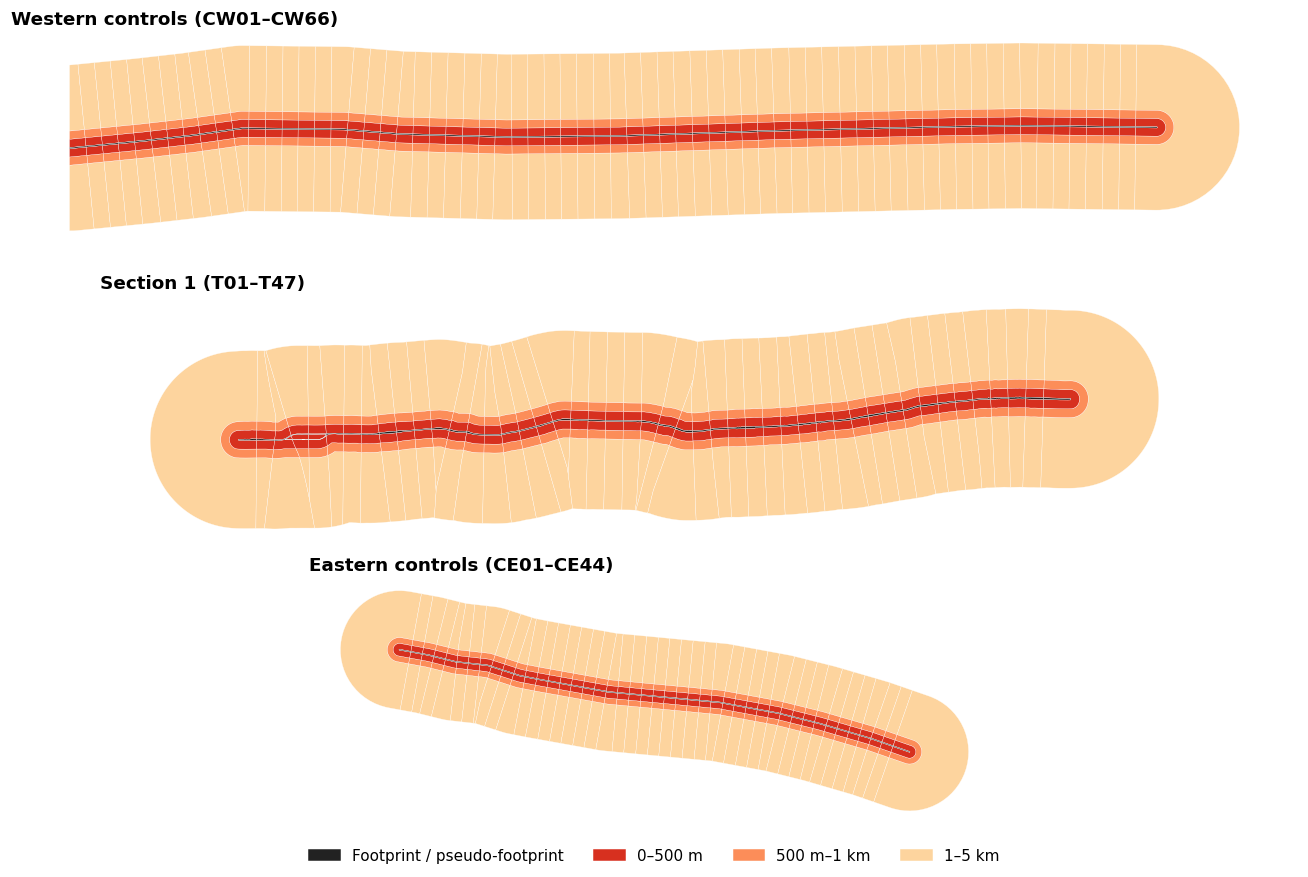

In [5]:
import geopandas as gpd
units = gpd.read_file(OUT / 'segment_zones_all.shp')
zcol = {'F': '#222222', 'B1': '#D7301F', 'B2': '#FC8D59', 'B3': '#FDD49E'}
fig, axs = plt.subplots(3, 1, figsize=(12, 8))
for ax, side, title in zip(axs, ['W', 'S1', 'E'], ['Western controls (CW01–CW66)', 'Section 1 (T01–T47)', 'Eastern controls (CE01–CE44)']):
    u = units[units.side == side]
    for z in ['B3', 'B2', 'B1', 'F']:
        u[u.zone == z].plot(ax=ax, color=zcol[z], edgecolor='white', linewidth=0.2)
    ax.set_title(title, loc='left', fontweight='bold'); ax.set_axis_off()
from matplotlib.patches import Patch
fig.legend([Patch(color=zcol[z]) for z in ['F', 'B1', 'B2', 'B3']],
           ['Footprint / pseudo-footprint', '0–500 m', '500 m–1 km', '1–5 km'], loc='lower center', ncol=4, frameon=False)
plt.tight_layout(rect=(0, 0.04, 1, 1)); plt.show()

The white lines are the segment boundaries. Each segment carries four units, one per zone. The bands include lagoon and sea; water pixels are excluded from every denominator later, so this does not affect the results.

## 5. Baseline covariates (DS2020) for every segment

Matching (notebook 03) needs a description of each segment before construction. The four zones of a segment are pooled:

| Covariate | Definition |
|---|---|
| `veg` | vegetation ÷ land (land = everything except water, DS2020) |
| `built` | built-up ÷ land |
| `bare` | (sand/bare + beach) ÷ land |
| `waterfrac` | water ÷ total area |
| `elev` | area-weighted mean SRTM elevation (m) |
| `dcbd_km` | distance from the segment midpoint to Lagos Island CBD (3.3896°E, 6.4549°N) |

In [6]:
from pyproj import Transformer
d = pd.read_csv(TAB / 'segment_zone_panel_DS2020_2026.csv')
cols = ['a_total', 'a_veg', 'a_built', 'a_sand', 'a_water', 'a_beach', 'elev_x_area', 'a_land2020']
b = d[d.year == 2020].groupby(['seg_id', 'treated', 'side'], as_index=False)[cols].sum()
b['veg'] = b.a_veg / b.a_land2020
b['built'] = b.a_built / b.a_land2020
b['bare'] = (b.a_sand + b.a_beach) / b.a_land2020
b['waterfrac'] = b.a_water / b.a_total
b['elev'] = b.elev_x_area / b.a_total

segs = pd.concat([gpd.read_file(VEC / 'S1_segments.shp')[['seg_id', 'geometry']],
                  gpd.read_file(OUT / 'C_segments.shp')[['seg_id', 'geometry']]])
mid = segs.set_index('seg_id').geometry.interpolate(0.5, normalized=True)
cx, cy = Transformer.from_crs(4326, 32631, always_xy=True).transform(3.3896, 6.4549)
b['dcbd_km'] = b.seg_id.map(np.hypot(mid.x - cx, mid.y - cy) / 1000)
b.to_csv(RES / 'seg_cov.csv', index=False)

ref = pd.read_csv(TAB / 'seg_cov.csv').set_index('seg_id')
diff = max(np.abs(b.set_index('seg_id').loc[ref.index, v] - ref[v]).max() for v in ['veg', 'built', 'bare', 'waterfrac', 'elev', 'dcbd_km'])
print(f'{len(b)} segments; largest difference from the covariates used in the paper: {diff:.1e}')
b[['seg_id', 'side', 'veg', 'built', 'bare', 'waterfrac', 'elev', 'dcbd_km']].round(3).head()

157 segments; largest difference from the covariates used in the paper: 1.4e-14


,seg_id,side,veg,built,bare,waterfrac,elev,dcbd_km
0,CE01,E,0.339,0.308,0.354,0.535,3.928,74.483
1,CE02,E,0.666,0.069,0.265,0.657,3.490,75.474
2,CE03,E,0.620,0.060,0.320,0.617,3.091,76.465
3,CE04,E,0.652,0.113,0.235,0.573,3.895,77.448
4,CE05,E,0.511,0.190,0.299,0.651,2.460,78.430


## 6. How different were Section 1 and the controls in 2020?

The **standardised mean difference** (SMD) compares group means in units of the pooled standard deviation:

$$\text{SMD} = \frac{\bar x_{S1} - \bar x_{C}}{\sqrt{(s^2_{S1} + s^2_{C})/2}}$$

|SMD| below 0.25 is usually taken as acceptable balance (Stuart, 2010).

In [7]:
T, C = b[b.treated == 1], b[b.treated == 0]
labels = {'veg': 'Vegetation share', 'built': 'Built-up share', 'bare': 'Bare/sand share',
          'waterfrac': 'Water share', 'elev': 'Mean elevation (m)', 'dcbd_km': 'Distance to CBD (km)'}
pd.DataFrame([{'covariate': labels[v], 'Section 1 mean': T[v].mean(), 'Control mean': C[v].mean(),
               'SMD': (T[v].mean() - C[v].mean()) / np.sqrt((T[v].var() + C[v].var()) / 2)}
              for v in labels]).round(2)

,covariate,Section 1 mean,Control mean,SMD
0,Vegetation share,0.40,0.67,-1.36
1,Built-up share,0.49,0.13,1.91
2,Bare/sand share,0.11,0.20,-1.06
3,Water share,0.48,0.51,-0.23
4,Mean elevation (m),3.88,3.36,0.39
5,Distance to CBD (km),27.79,64.03,-1.52


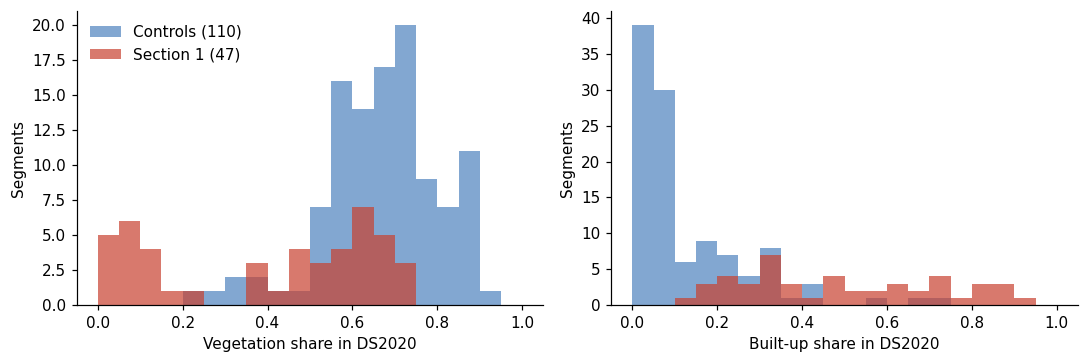

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, v in zip(axs, ['veg', 'built']):
    bins = np.linspace(0, 1, 21)
    ax.hist(C[v], bins, color='#2F6DB3', alpha=0.6, label='Controls (110)')
    ax.hist(T[v], bins, color='#C8412F', alpha=0.7, label='Section 1 (47)')
    ax.set_xlabel(labels[v] + ' in DS2020'); ax.set_ylabel('Segments')
axs[0].legend(frameon=False)
plt.tight_layout(); plt.show()

**Interpretation.** Section 1 was already much more urbanised than the control coast in 2020: built-up share 0.49 vs 0.13 (SMD +1.9) and vegetation 0.40 vs 0.67 (SMD −1.4). A simple comparison would therefore be unfair, because urban fringes lose vegetation faster anyway. Notebook 03 fixes this by **matching** each Section 1 segment to the control segments most similar to it in 2020.